<a href="https://colab.research.google.com/github/AbdouSalamSisawo/TensorOrbit-EDA-Bootcamp/blob/main/day-2-numpy-matplotlib/Practice%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Loaded directly from GitHub so it works in any Colab session, no upload needed
df = pd.read_csv('https://raw.githubusercontent.com/AbdouSalamSisawo/TensorOrbit-EDA-Bootcamp/main/day-2-numpy-matplotlib/sustainability_cities.csv')
df.head()

,city,country,year,population,co2_emissions_tons_per_capita,renewable_energy_pct,recycling_rate_pct,energy_consumption_kwh_per_capita,water_usage_liters_per_capita,green_space_pct
0,Lagos,Nigeria,2021,2056361,4.24,24.4,14.1,2550.5,179.1,9.8
1,Lome,Togo,2020,4007740,3.97,33.2,17.3,1075.5,224.3,23.2
2,Cotonou,Benin,2019,4829788,2.20,47.4,25.1,834.0,260.1,13.4
3,Addis Ababa,Ethiopia,2020,3043778,1.28,35.9,30.2,1070.1,199.2,26.9
4,Abidjan,Ivory Coast,2022,5707658,5.75,26.4,10.9,620.4,62.7,5.3


In [ ]:
co2 = df['co2_emissions_tons_per_capita'].to_numpy()
co2[:10]

array([4.24, 3.97, 2.2 , 1.28, 5.75, 4.5 , 4.18, 3.67, 3.98,  nan])

In [ ]:
print(co2[0])       # first value
print(co2[:5])      # first 5
print(co2[-3:])     # last 3

4.24
[4.24 3.97 2.2  1.28 5.75]
[3.85 1.79 4.3 ]


In [ ]:
recycle = df['recycling_rate_pct'].to_numpy()
renewable = df['renewable_energy_pct'].to_numpy()

combined_score = (recycle + renewable) / 2
print(combined_score[:10])

[19.25 25.25 36.25 33.05 18.65 44.55 28.55 25.25 40.95 44.4 ]


In [ ]:
high_co2_mask = co2 > 3
print(high_co2_mask[:10])
print(co2[high_co2_mask][:10])   # only the high-CO2 values

# np.where: label values instead of just filtering
labels = np.where(co2 > 3, 'high', 'low')
print(labels[:10])

[ True  True False False  True  True  True  True  True False]
[4.24 3.97 5.75 4.5  4.18 3.67 3.98 3.62 3.59 9.36]
['high' 'high' 'low' 'low' 'high' 'high' 'high' 'high' 'high' 'low']


In [ ]:
print(np.sort(co2)[:5])   # 5 lowest
print(np.sort(co2)[-5:])  # 5 highest

[0.86 0.92 0.96 1.   1.02]
[nan nan nan nan nan]


In [ ]:
print('Mean CO2:', np.nanmean(co2))
print('Median CO2:', np.nanmedian(co2))
print('Std Dev CO2:', np.nanstd(co2))

Mean CO2: 3.6829896907216506
Median CO2: 3.56
Std Dev CO2: 3.46860563949953


In [ ]:
q1 = np.nanpercentile(co2, 25)
q3 = np.nanpercentile(co2, 75)
print('Q1:', q1, '| Q3:', q3)

Q1: 1.79 | Q3: 4.3


In [ ]:
clean = df.dropna(subset=['co2_emissions_tons_per_capita', 'recycling_rate_pct'])
corr_matrix = np.corrcoef(clean['co2_emissions_tons_per_capita'], clean['recycling_rate_pct'])
print('Correlation coefficient:', corr_matrix[0, 1])

Correlation coefficient: -0.1567600738929963


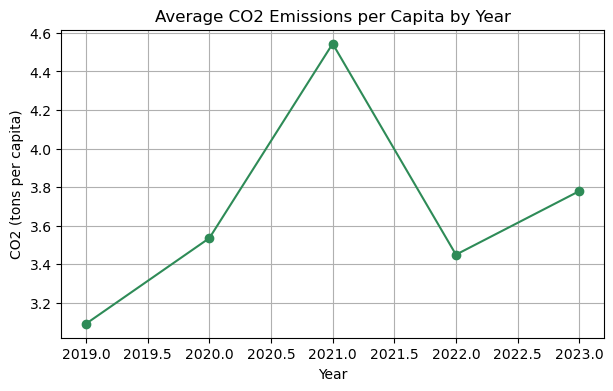

In [ ]:
yearly_avg = df.groupby('year')['co2_emissions_tons_per_capita'].mean()

plt.figure(figsize=(7,4))
plt.plot(yearly_avg.index, yearly_avg.values, marker='o', color='seagreen')
plt.title('Average CO2 Emissions per Capita by Year')
plt.xlabel('Year')
plt.ylabel('CO2 (tons per capita)')
plt.grid(True)
plt.show()

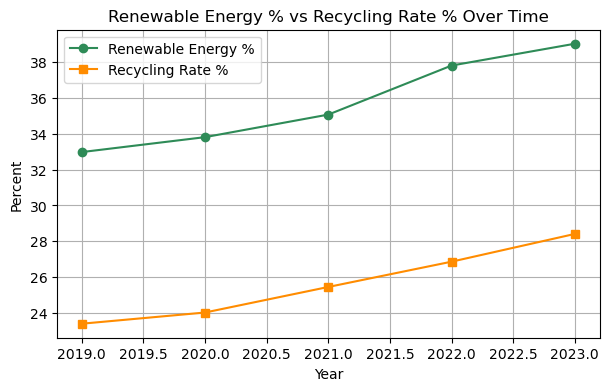

In [ ]:
yearly_renew = df.groupby('year')['renewable_energy_pct'].mean()
yearly_recycle = df.groupby('year')['recycling_rate_pct'].mean()

plt.figure(figsize=(7,4))
plt.plot(yearly_renew.index, yearly_renew.values, marker='o', label='Renewable Energy %', color='seagreen')
plt.plot(yearly_recycle.index, yearly_recycle.values, marker='s', label='Recycling Rate %', color='darkorange')
plt.title('Renewable Energy % vs Recycling Rate % Over Time')
plt.xlabel('Year')
plt.ylabel('Percent')
plt.legend()
plt.grid(True)
plt.show()

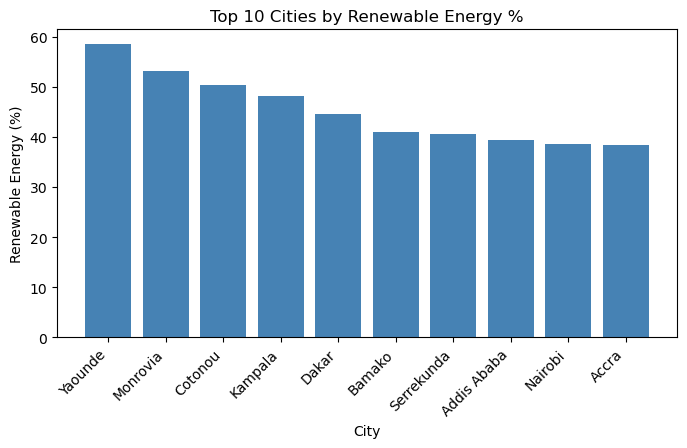

In [ ]:
top10 = df.groupby('city')['renewable_energy_pct'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,4))
plt.bar(top10.index, top10.values, color='steelblue')
plt.title('Top 10 Cities by Renewable Energy %')
plt.xlabel('City')
plt.ylabel('Renewable Energy (%)')
plt.xticks(rotation=45, ha='right')
plt.show()

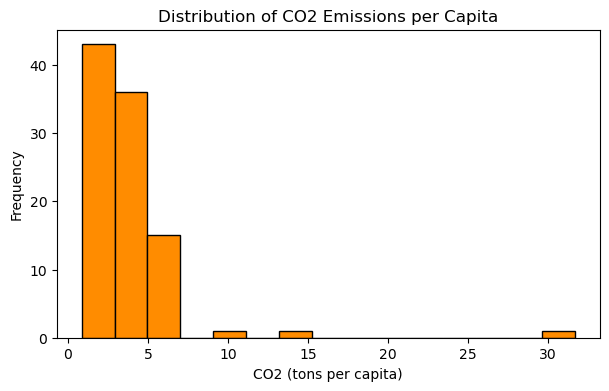

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(df['co2_emissions_tons_per_capita'].dropna(), bins=15, color='darkorange', edgecolor='black')
plt.title('Distribution of CO2 Emissions per Capita')
plt.xlabel('CO2 (tons per capita)')
plt.ylabel('Frequency')
plt.show()


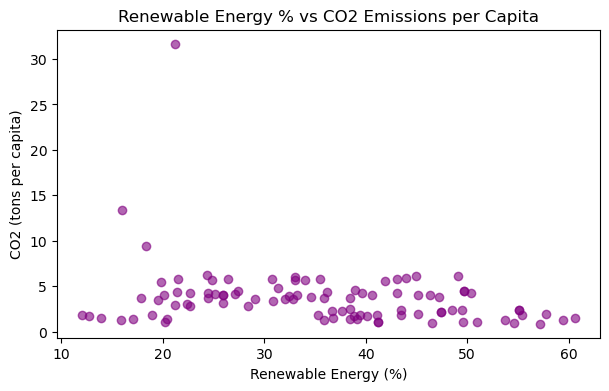

In [ ]:
plt.figure(figsize=(7,4))
plt.scatter(df['renewable_energy_pct'], df['co2_emissions_tons_per_capita'], alpha=0.6, color='purple')
plt.title('Renewable Energy % vs CO2 Emissions per Capita')
plt.xlabel('Renewable Energy (%)')
plt.ylabel('CO2 (tons per capita)')
plt.show()

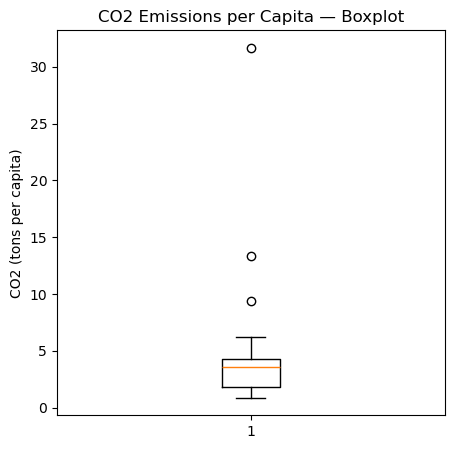

In [ ]:
plt.figure(figsize=(5,5))
plt.boxplot(df['co2_emissions_tons_per_capita'].dropna(), vert=True)
plt.title('CO2 Emissions per Capita — Boxplot')
plt.ylabel('CO2 (tons per capita)')
plt.show()

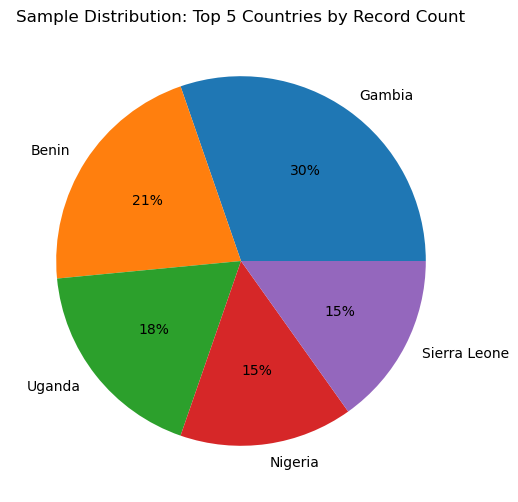

In [ ]:
country_counts = df['country'].value_counts().head(5)

plt.figure(figsize=(6,6))
plt.pie(country_counts.values, labels=country_counts.index, autopct='%1.0f%%')
plt.title('Sample Distribution: Top 5 Countries by Record Count')
plt.show()

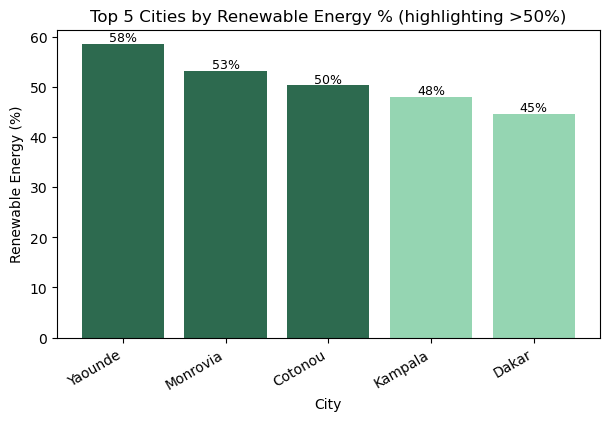

In [ ]:
plt.figure(figsize=(7,4))
bars = plt.bar(top10.index[:5], top10.values[:5], color=['#2D6A4F' if v > 50 else '#95D5B2' for v in top10.values[:5]])
plt.title('Top 5 Cities by Renewable Energy % (highlighting >50%)')
plt.xlabel('City')
plt.ylabel('Renewable Energy (%)')
plt.xticks(rotation=30, ha='right')

# Annotate each bar with its value
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.0f}%', ha='center', fontsize=9)

plt.show()

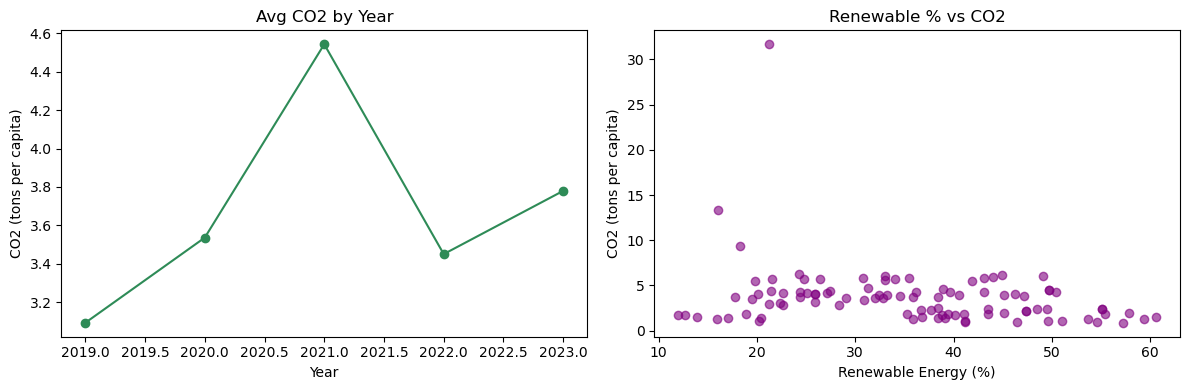

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(yearly_avg.index, yearly_avg.values, marker='o', color='seagreen')
axes[0].set_title('Avg CO2 by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('CO2 (tons per capita)')

axes[1].scatter(df['renewable_energy_pct'], df['co2_emissions_tons_per_capita'], alpha=0.6, color='purple')
axes[1].set_title('Renewable % vs CO2')
axes[1].set_xlabel('Renewable Energy (%)')
axes[1].set_ylabel('CO2 (tons per capita)')

plt.tight_layout()
plt.show()

done